# Mini-Projekt für Analyse von Iris Datensatz und Klassifikation
## Aufgabenbeschreibung:

1. **Datenanalyse der Iris-Datensätze**: Durchführung einer explorativen Datenanalyse (**EDA**), um Struktur, Verteilung und Zusammenhänge der Merkmale zu untersuchen.

2. **Klassifikation mit k-Nearest-Neighbors**: Einsatz des k-Nearest-Neighbors-Algorithmus zur Vorhersage der Klassenzugehörigkeit neuer Iris-Beobachtungen.

3. **Einfluss von Skalierungsmethoden**: Anwendung verschiedener Skalierungsverfahren sowie Vergleich der Klassifikationsleistung mit zwei Algorithmen: **KNeighborsClassifier und RadiusNeighborsClassifier**.

4. **Einsatz von Pipelines**: Umsetzung der Datenvorverarbeitung und Modellierung mithilfe der Pipeline-Technik, um eine reproduzierbare und modulare Softwarelösung zu gewährleisten.

5. **Bewertung der Ergebnisse**: Analyse und Interpretation der Klassifikationsergebnisse auf Basis der Iris-Daten sowie Diskussion der Eignung der gewählten Verfahren für dieses Klassifikationsproblem.


# Einlesen von Iris Daten

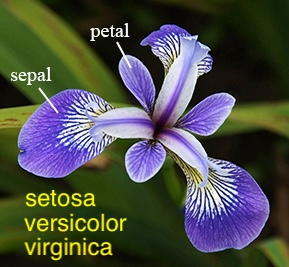
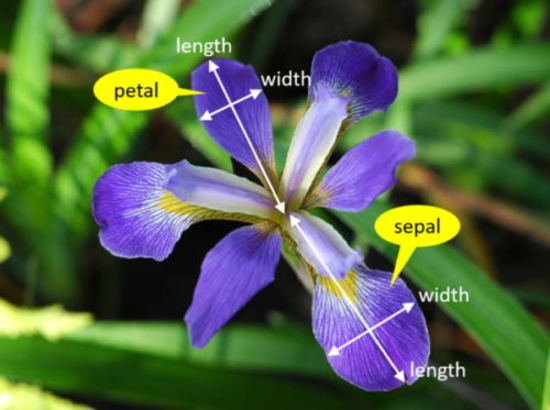
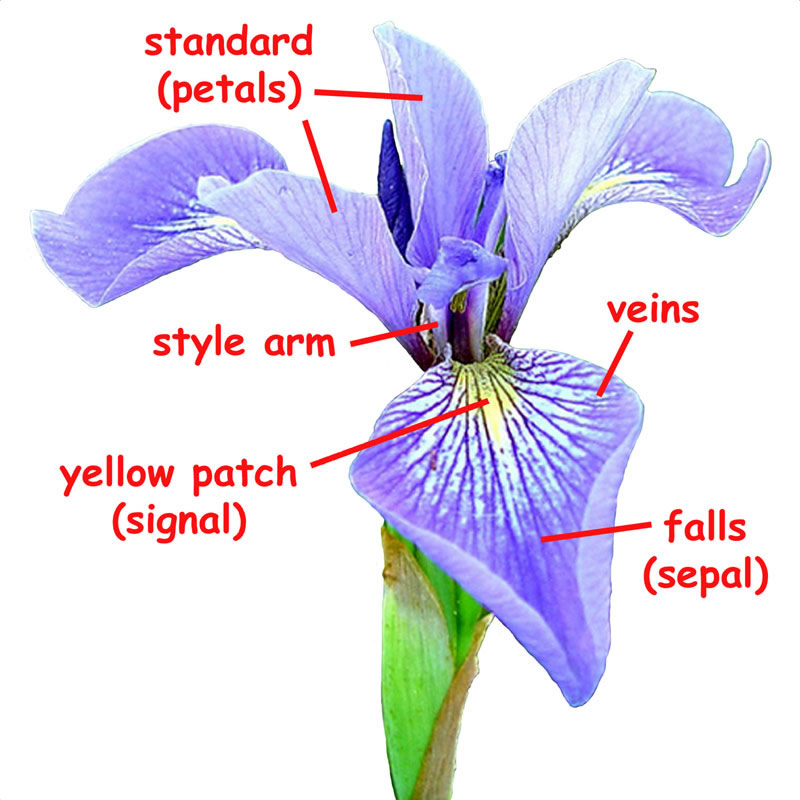


# EDA (explorative data analyse)

## Diagonal: Das Bild ist kde(Kernel Density Estimation) erzeugt. Es dient für bessere Tennung von Iris-Arten. Es kann zwischen diag_kind="hist" und "kde" im Code wechseln.
 1. sepallenght: setosa, versicolor, virginica
 2. sepalwidth:  setosa, versicolor, virginica
 3. petalenght: setosa, versicolor, virginica
 4. petawidth:  setosa, versicolor, virginica

  
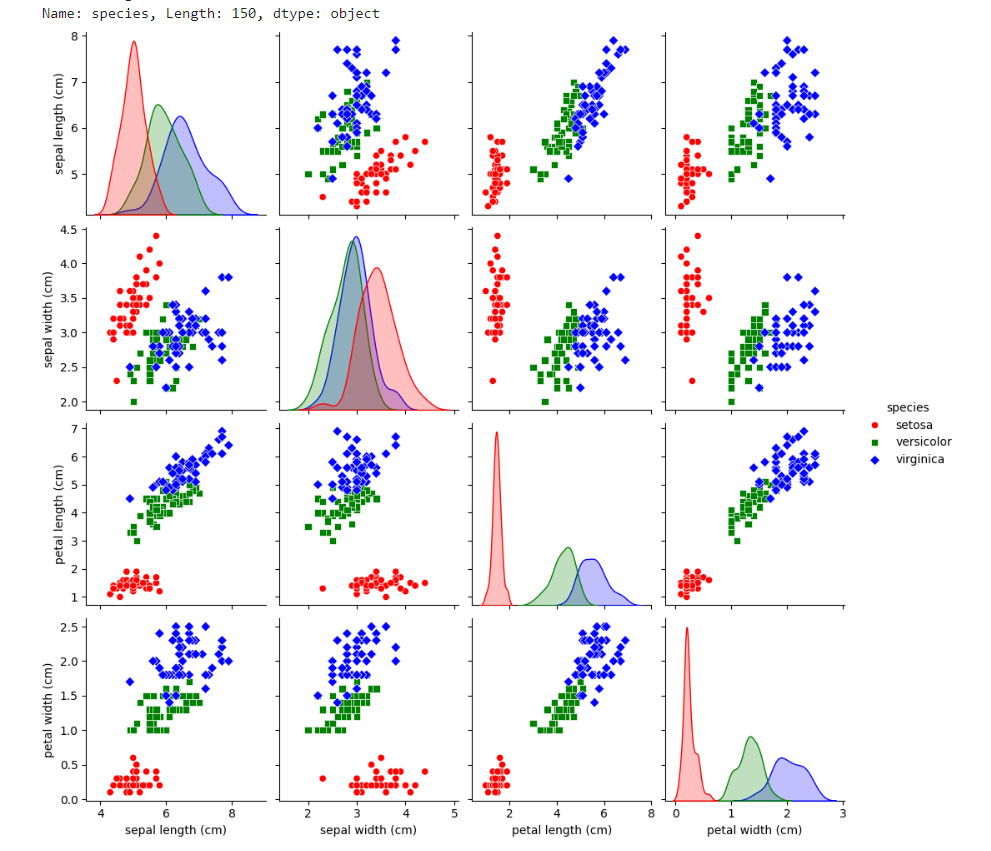

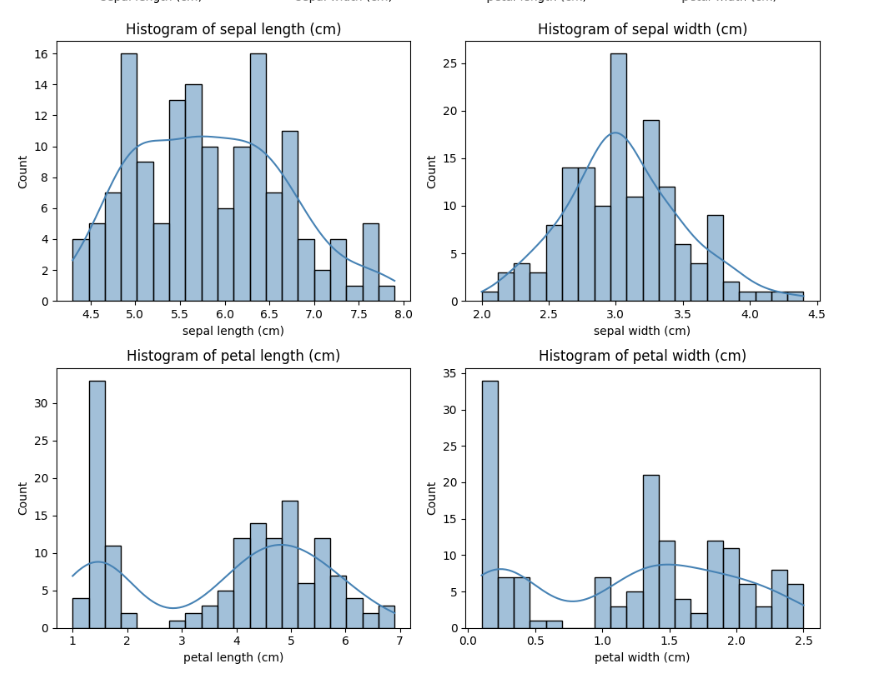


## pairplot
1. Die drei Iris-Spezies (Setosa, Versicolor, Virginica) sind farblich und durch Marker klar getrennt → schnelle Erkennbarkeit.

2. Setosa (rot, Kreise) ist sehr gut von den anderen Arten trennbar (v. a. bei den Petal-Features).

3. Versicolor und Virginica stärker überlappen, während Setosa fast immer separat liegt.

## Histogram
1. **Sepal Length (oben links)**

Verteilung: relativ symmetrisch, leicht multimodal.

KDE: glatte Kurve folgt grob der Histogrammform.

Interpretation: Es gibt mehrere "Peaks", was auf unterschiedliche Iris-Arten hinweisen könnte.

Fazit: Histogramm sinnvoll, zeigt Streuung und zentrale Tendenz gut.

2. **Sepal Width (oben rechts)**

Verteilung: eher leicht rechtsschief (tail nach rechts).

KDE: passt gut zur Form des Histogramms.

Besonderheit: Ein klarer Modus um 3.0 cm, Peak deutet auf häufigste Sepal Width.

Fazit: Informativ, einfach zu interpretieren.

3. **Petal Length (unten links)**

Verteilung: stark bimodal, zwei deutliche Cluster (kleine und große Petals).

KDE: zeigt die bimodale Struktur schön.

Interpretation: Sehr typisch für Iris-Datensatz, da einige Arten kleine Petals, andere große haben.

Fazit: Histogramm zeigt die Unterschiede zwischen Arten sehr gut.

4. **Petal Width (unten rechts)**

Verteilung: ebenfalls bimodal, etwas "unregelmäßig" durch wenige extreme Werte.

KDE: reflektiert zwei Hauptcluster.

Interpretation: Auch hier Trennung der Arten sichtbar, aber weniger ausgeprägt als Petal Length.

Fazit: Hilfreich, zeigt Cluster-Struktur.


In [9]:
# https://scikit-learn.org/stable/api/sklearn.neighbors.html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris


# Iris-Datensatz laden
data_iris=load_iris()
print(data_iris.feature_names)
print(data_iris.target_names)

XTrain_iris, yTrain_iris = (data_iris.data , data_iris.target)
#print( XTrain_iris.shape, XTrain_iris)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


data_iris.feature_names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
speicis##### (150,) 0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object


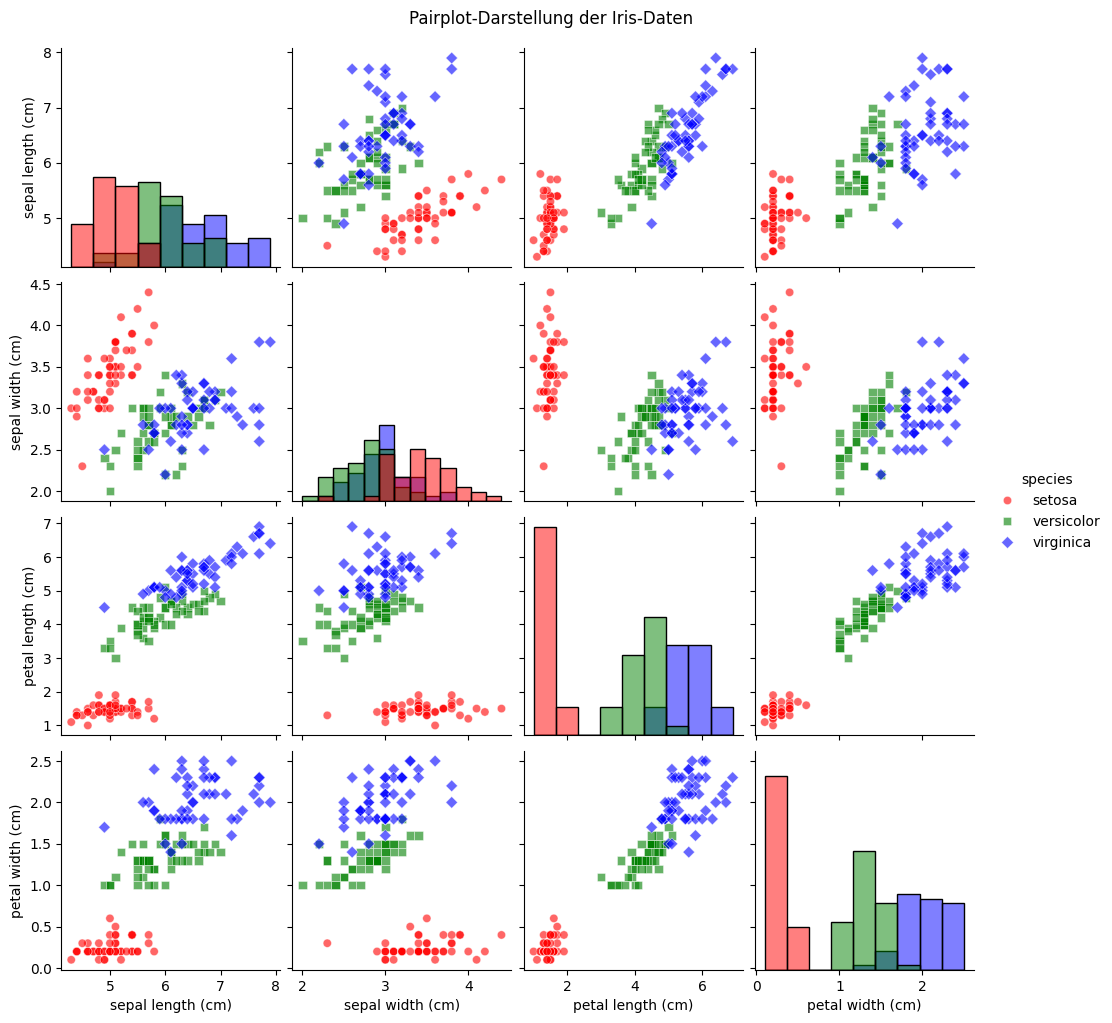

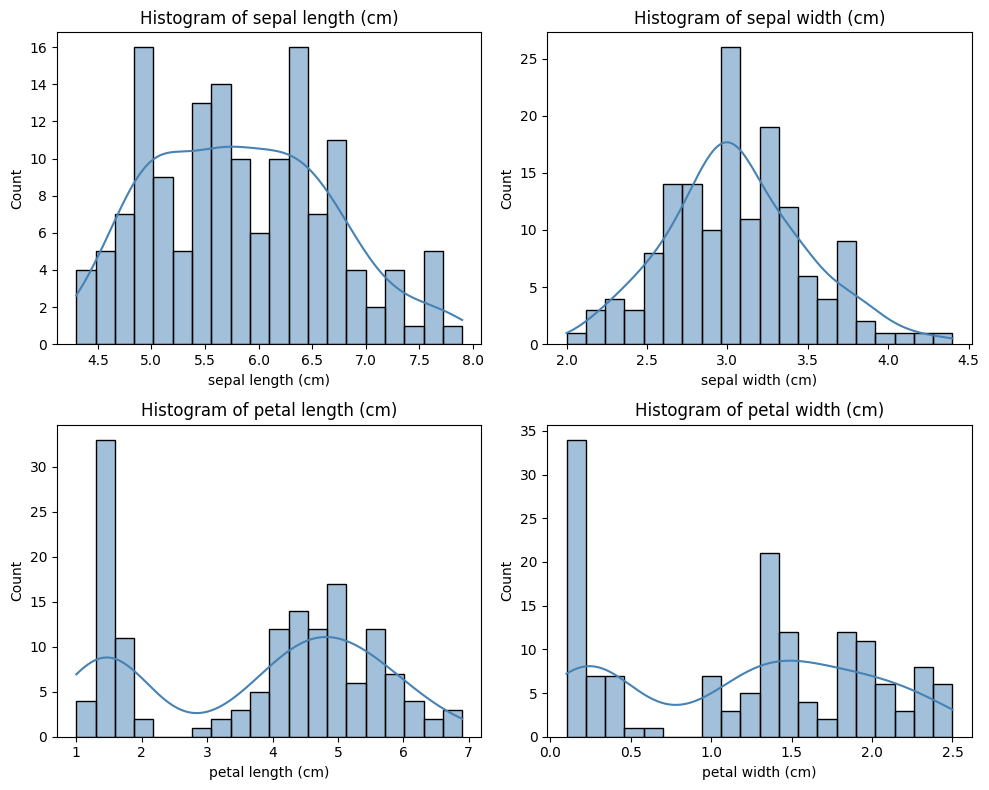

In [10]:
# plot with pandas:
print("data_iris.feature_names:", data_iris.feature_names)
df = pd.DataFrame(data_iris.data, columns=data_iris.feature_names)
df["species"] = [data_iris.target_names[i] for i in data_iris.target] # add a new col: "specis" (1,2,3) for the plot
#df["species"] =  pd.DataFrame(data_iris.target)
print("speicis#####", df["species"].shape, df["species"])
# Pairplot
#sns.pairplot(df, hue="species", diag_kind="kde", markers=["o", "s", "D"], palette=["red", "green", "blue"])
sns.pairplot(df, hue="species", diag_kind="hist", markers=["o", "s", "D"],plot_kws={"alpha": 0.6}, palette=["red", "green", "blue"])

plt.suptitle("Pairplot-Darstellung der Iris-Daten", y=1.02)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
feutures= data_iris.feature_names

for i, feature in enumerate(data_iris.feature_names):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[feature], bins=20, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()



In [11]:
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

# Features
features = data_iris.feature_names

# 2x2 Subplot-Grid erstellen
fig = sp.make_subplots(rows=2, cols=2, subplot_titles=features)

# Schleife über alle Features
for i, feature in enumerate(features):
    row = i // 2 + 1
    col = i % 2 + 1

    # Histogram mit Plotly Express erzeugen
    hist = px.histogram(df, x=feature, nbins=40, color_discrete_sequence=["steelblue"])

    # Trace (Balken) in Subplot hinzufügen
    for trace in hist.data:
        fig.add_trace(trace, row=row, col=col)

# Layout anpassen
fig.update_layout(
    height=1000, width=1200,
    title_text="Histograms of Iris Features",
    showlegend=False
)

fig.show()


# Aufbau von Pipeline

## 1. scalers_selected = [StandardScaler(), MinMaxScaler(), RobustScaler()]
## 2. Classifier: KNeighborsClassifier(), RadiusNeighborsClassifier() 
 **models_selected** = [
    KNeighborsClassifier(),
    RadiusNeighborsClassifier()
]

 KNeighborsRegressor braucht stetige Werte. Die Zielwerte in iris-Datensätzen sind kategorische Werte. So is es nicht geeignet für iris-Datensätze Klassifikation
## 3. param_grid = {
    "KNeighborsClassifier": {"n_neighbors": [1, 3, 5],  "weights":['uniform','distance'] },  # option: "p": [1,2, 50] behind "weights"
    "RadiusNeighborsClassifier": {"radius": [1.0, 2.0, 5.0],  "weights":['uniform','distance']} # option: "p": [1,2, 50] behind "weights"
}

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor,  RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

from itertools import product


#XTrain_iris, yTrain_iris = (data_iris.data , data_iris.target)
# split the data 
X_train, X_test, y_train, y_test = train_test_split(XTrain_iris, yTrain_iris, test_size=0.2, random_state=42)

# set Transformer
scalers_selected = [StandardScaler(), MinMaxScaler(), RobustScaler()]

# Modelle (KNN Varianten)
models_selected = [
    KNeighborsClassifier(),
    RadiusNeighborsClassifier()
]

# allgemeiner Aufbau von Parameter-Grids, neue Parameter können im sub-Dict{} für Classifier erweitert werden
param_grid = {
    "KNeighborsClassifier": {"n_neighbors": [1, 3, 5],  "weights":['uniform','distance'] },  # option: "p": [1,2, 50] behind "weights"
    "RadiusNeighborsClassifier": {"radius": [1.0, 2.0, 5.0],  "weights":['uniform','distance']} # option: "p": [1,2, 50] behind "weights"
}

# Ergebnisse sammeln
results = []

for scaler in scalers_selected:
    for model in models_selected:
        model_name = model.__class__.__name__   # KNeighborsClassifier, RadiusNeighborsClassifier
        # get the parameter for the model according to the model_name
        # params is a dict. with some items for parameters: {"n_neighbors": [1, 3, 5],  "weights":['uniform','distance'] }
        params = param_grid[model_name]         # model_name as key: key1: KNeighborsClassifier, key2: RadiusNeighborsClassifier
        print("scalar=", scaler," und parameters=", params)
        print("---------------------------")
        # * : um eine Liste/Tuple beim Funktionsaufruf in einzelne Argumente zu zerlegen. 
        keys, values = zip(*params.items()) #  *params.items(): trennt Schlüssel und Werte auf: in keys und values
        #print("tuple(keys), tuple(values): ", keys, values)
        # *value: entpacken values in zwei Teilen: [1, 3, 5] und ['uniform','distance'] 
        # product erzeugt alle möglichen Kombinationen aus den Values.
        # 1, 'uniform'
        # 1, 'distance'
        # 3, 'uniform'
        # 3, 'distance'
        # 5, 'uniform'
        # 5, 'distance'
        # values= ([1, 3, 5] , ['uniform','distance'])
        
        for combo in product(*values): # compo is a tupel with 2 elements, z.B. (1, 'uniform')
            #print("combo: ", combo)
            # bauen ein dict:   keys: ('n_neighbors', 'weights'), combo: z.b. (1, 'uniform')
            # param_dict= {'n_neighbors':1,  'weights': 'uniform')
            param_dict = dict(zip(keys, combo)) 
            model_instance = model.__class__(**param_dict) #entpackt Dictionary zu Keyword-Argumenten: z.B. ("n_neighbors"=3, 'weights'='uniform')

            # Pipeline bauen
            pipe = Pipeline([
                ("scaler", scaler),
                ("model", model_instance)
                   ])
            
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_train)
            score = accuracy_score(y_train, y_pred)           
            y_pred_test = pipe.predict(X_test)
            score_test = accuracy_score(y_test, y_pred_test)

            results.append((scaler.__class__.__name__, model_name, param_dict, score, score_test))

# Ergebnisse ausgeben
for scaler_name, model_name, param_dict, score, score_test in results:
    print(f"Scaler={scaler_name:15} | Model={model_name:25} | Params={param_dict} | Score={score:.3f}, ScoreTest={score_test:.3f}")



scalar= StandardScaler()  und parameters= {'n_neighbors': [1, 3, 5], 'weights': ['uniform', 'distance']}
---------------------------
scalar= StandardScaler()  und parameters= {'radius': [1.0, 2.0, 5.0], 'weights': ['uniform', 'distance']}
---------------------------
scalar= MinMaxScaler()  und parameters= {'n_neighbors': [1, 3, 5], 'weights': ['uniform', 'distance']}
---------------------------
scalar= MinMaxScaler()  und parameters= {'radius': [1.0, 2.0, 5.0], 'weights': ['uniform', 'distance']}
---------------------------
scalar= RobustScaler()  und parameters= {'n_neighbors': [1, 3, 5], 'weights': ['uniform', 'distance']}
---------------------------
scalar= RobustScaler()  und parameters= {'radius': [1.0, 2.0, 5.0], 'weights': ['uniform', 'distance']}
---------------------------
Scaler=StandardScaler  | Model=KNeighborsClassifier      | Params={'n_neighbors': 1, 'weights': 'uniform'} | Score=1.000, ScoreTest=1.000
Scaler=StandardScaler  | Model=KNeighborsClassifier      | Params={'n

# Bewertung der Ergebnisse
## KNeighborsClassifier

Mit n_neighbors=1 → fast immer perfekte Scores (Train=1.0, Test=1.0).
Das ist typisch: bei KNN mit k=1 passt sich das Modell perfekt den Trainingsdaten an → Overfitting-Gefahr.

Mit n_neighbors=3 oder 5:

Scores im Training leicht kleiner (0.94–0.96), aber Test bleibt bei 1.0.

→ Das ist sogar besser, weil es robuster generalisiert.

weights= distance: immer perfekt (Train=1.0, Test=1.0). das ist verdächtig

Fazit: KNeighborsClassifier mit k=3 oder 5 ist wahrscheinlich die stabilere Wahl als k=1.

## RadiusNeighborsClassifier

Bei weights='uniform' und kleinen Radien (1.0, 2.0): bessere Ergebnisse als Radius=5.0 bei 'weights'='uniform'} 

Bei weights='distance': immer perfekt (Train=1.0, Test=1.0), auch bei großen Radien (2.0 oder 5.0).

→ hier ist der Trick: mit Distanzgewichtung bekommen die näheren Punkte mehr Einfluss → dadurch wird das Problem gelöst, dass zu viele Nachbarn in großen Radien einbezogen werden.

Fazit: RadiusNeighborsClassifier mit weights="distance" ist extrem stark, fast schon „zu perfekt“.

## Einfluss der Skalierung

StandardScaler und RobustScaler → liefern ziemlich ähnliche Ergebnisse bei KNeighborsClassifier.

RadiusNeighbors + uniform ist stark abhängig von der Skalierung → besonders MinMaxScaler schneidet hier schlechter ab.
(Das macht Sinn, da MinMax extreme Werte komprimiert und Abstände im Raum verändert.)

Fazit: für KNN sind StandardScaler oder RobustScaler am zuverlässigsten. StandardScaler ist das beste
RadiusNeighbors ist deutlich empfindlicher auf die Wahl des Scalers.

## Einfluss von "Distance": alle sind perfekt. 
Das könnte bedeuten, dass der Datensatz „zu einfach“ ist (z. B. Iris), oder dass Distance-Weights hier alle Fehler ausbügeln. sehr verdächtig.
